# 4 — Évaluation et sélection du modèle (CRISP-DM Phase 5)

Ce notebook agrège les résultats des quatre notebooks de modélisation (`3a` à `3d`), produit la **comparaison inter-familles** et désigne le modèle champion qui sera utilisé pour la soumission Kaggle (NB5).

**Pré-requis** : avoir exécuté `3a_scaled_models.ipynb`, `3b_sklearn_trees.ipynb`, `3c_native_boosting.ipynb`, `3d_stacking.ipynb` au moins une fois — chacun écrit son fichier `results/family_<nom>.json`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path('results')

## 5.1 Agrégation des résultats

In [2]:
result_files = sorted(RESULTS_DIR.glob('family_*.json'))
print(f"Fichiers trouvés : {len(result_files)}")
for p in result_files:
    print(f"  - {p.name}")

if not result_files:
    raise RuntimeError("Aucun fichier results/family_*.json trouvé. "
                       "Exécuter 3a/3b/3c/3d d'abord.")

all_results = []
for p in result_files:
    all_results.extend(json.loads(p.read_text()))

results_df = pd.DataFrame(all_results).sort_values('holdout_rmsle').reset_index(drop=True)
print(f"\nNombre total de modèles agrégés : {len(results_df)}")
display(results_df[['family', 'model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

Fichiers trouvés : 4
  - family_native_boosting.json
  - family_scaled.json
  - family_sklearn_trees.json
  - family_stacking.json

Nombre total de modèles agrégés : 15


,family,model,cv_rmsle,holdout_rmsle,fit_time_s
0,stacking,Stacking,NaN,0.112202,13.012356
1,sklearn_trees,GradientBoosting,0.125168,0.115419,2.482807
2,scaled,SVR,0.117750,0.115885,4.957137
3,scaled,Lasso,0.119997,0.116451,0.156636
4,scaled,OLS,0.121470,0.116999,0.299021
5,native_boosting,XGBoost_onehot,0.123717,0.117796,2.095810
6,scaled,ElasticNet,0.119578,0.118910,0.592950
7,native_boosting,XGBoost_tuned,0.117110,0.119286,1.202769
8,native_boosting,XGBoost_native,0.125556,0.121032,2.683081
9,scaled,Ridge,0.119154,0.123716,0.540133


## 5.2 Comparaison inter-familles (RMSLE holdout)

C'est le graphique central de la Phase 5 : tous les modèles, toutes familles confondues, classés par performance sur le jeu de test.

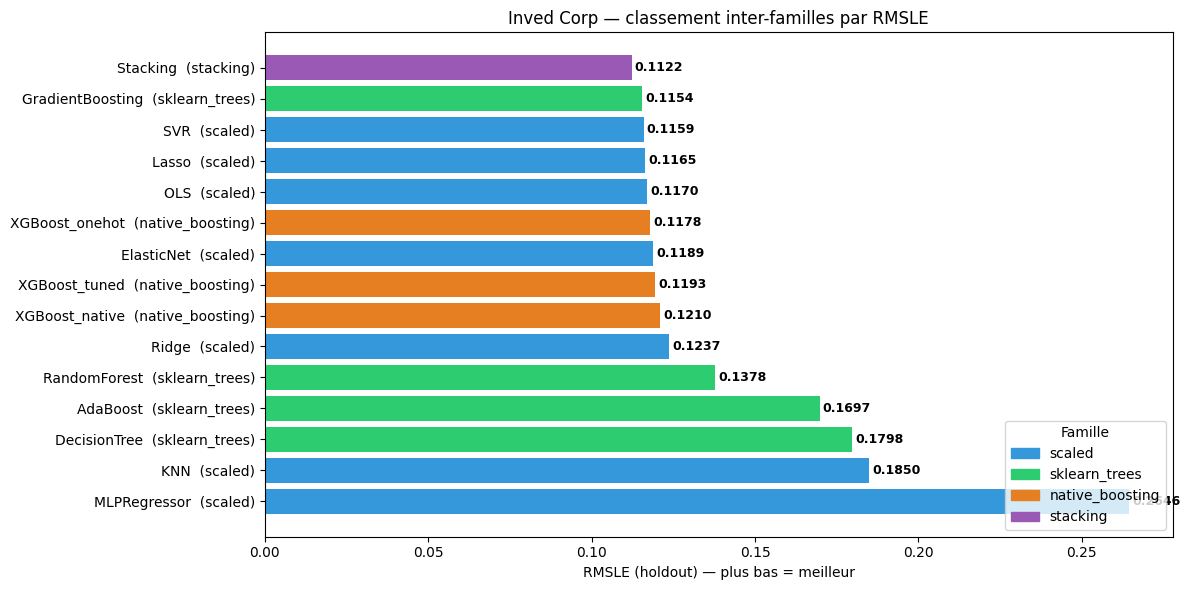

In [3]:
palette = {'scaled': '#3498db', 'sklearn_trees': '#2ecc71', 'native_boosting': '#e67e22', 'stacking': '#9b59b6'}
colors = [palette.get(f, '#888') for f in results_df['family']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(results_df)), results_df['holdout_rmsle'], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels([f"{r['model']}  ({r['family']})" for _, r in results_df.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('RMSLE (holdout) — plus bas = meilleur')
ax.set_title("Inved Corp — classement inter-familles par RMSLE")

for bar, v in zip(bars, results_df['holdout_rmsle']):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va='center', fontweight='bold', fontsize=9)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title='Famille', loc='lower right')
plt.tight_layout()
plt.show()

## 5.3 CV RMSLE vs Holdout RMSLE — vérification de cohérence

Un grand écart entre CV et holdout pour un modèle signale un risque de surapprentissage (CV optimiste) ou de chance du split (holdout chanceux). Idéalement, les deux métriques sont proches : c'est le signe d'un modèle qui *généralise* bien.

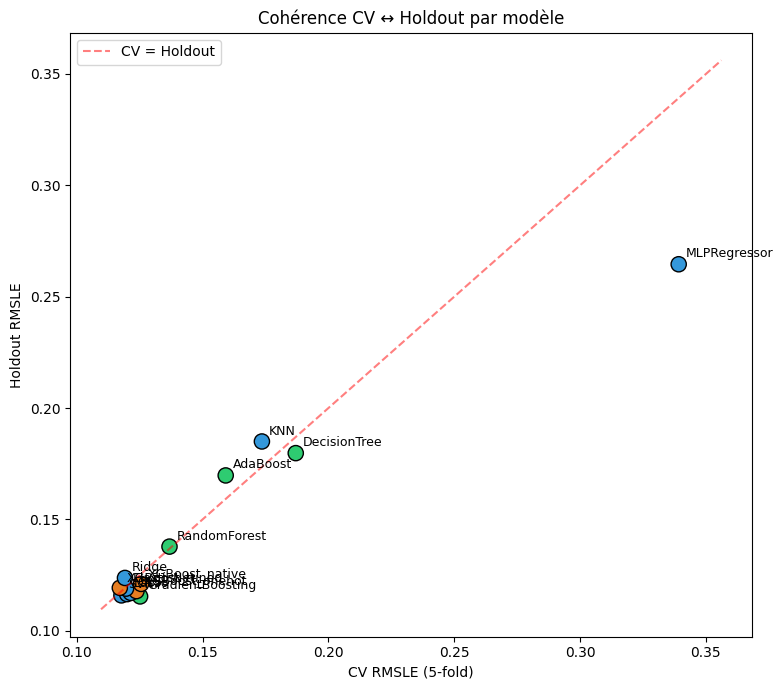

In [4]:
mask = results_df['cv_rmsle'].notna()
fig, ax = plt.subplots(figsize=(8, 7))
sub = results_df[mask]
ax.scatter(sub['cv_rmsle'], sub['holdout_rmsle'],
           c=[palette.get(f, '#888') for f in sub['family']], s=120, edgecolor='black')
for _, r in sub.iterrows():
    ax.annotate(r['model'], (r['cv_rmsle'], r['holdout_rmsle']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
lims = [min(sub['cv_rmsle'].min(), sub['holdout_rmsle'].min()) * 0.95,
        max(sub['cv_rmsle'].max(), sub['holdout_rmsle'].max()) * 1.05]
ax.plot(lims, lims, 'r--', alpha=0.5, label='CV = Holdout')
ax.set_xlabel('CV RMSLE (5-fold)')
ax.set_ylabel('Holdout RMSLE')
ax.set_title("Cohérence CV ↔ Holdout par modèle")
ax.legend()
plt.tight_layout()
plt.show()

## 5.4 Désignation du champion

In [5]:
winner = results_df.iloc[0].to_dict()
print(f"Champion : {winner['model']}   (famille : {winner['family']})")
print(f"   CV RMSLE      : {winner['cv_rmsle']}")
print(f"   Holdout RMSLE : {winner['holdout_rmsle']:.4f}")
print(f"   fit_time      : {winner['fit_time_s']:.2f}s")
print(f"   params        : {winner.get('params')}")

(RESULTS_DIR / 'winning_model.json').write_text(json.dumps(winner, indent=2, default=str))
print(f"\nÉcrit : {RESULTS_DIR / 'winning_model.json'}")

Champion : Stacking   (famille : stacking)
   CV RMSLE      : nan
   Holdout RMSLE : 0.1122
   fit_time      : 13.01s
   params        : {'meta': 'RidgeCV', 'base': ['Lasso', 'GBR', 'XGB']}

Écrit : results/winning_model.json


## 5.5 Dissertation : *« qu'est-ce qu'un bon modèle ? »*

> *Section à étoffer collectivement par l'équipe. Le squelette ci-dessous structure les idées que la consigne attend.*

### 5.5.1 Trois axes d'évaluation
- **Performance** : RMSLE sur le holdout (visible sur les graphiques 5.2 et 5.3).
- **Coût** : temps d'entraînement (colonne `fit_time_s`) + complexité de mise en production (Stacking + 3 base learners ≠ Lasso seul).
- **Interprétabilité** : un coefficient Lasso est compréhensible par un consultant immobilier ; un Stacking de 3 modèles est plus opaque.

### 5.5.2 Hiérarchie des modèles dans notre contexte Inved Corp
1. **Performance pure** : voir le classement 5.2.
2. **Performance ajustée au coût opérationnel** : XGBoost tuné est *probablement* préférable au Stacking si la dégradation est < 1 % RMSLE — un seul artefact joblib plutôt que quatre.
3. **Performance ajustée à l'interprétabilité** : Lasso reste un excellent candidat de secours quand le consultant doit *expliquer* la prédiction au client.

### 5.5.3 Limites par modèle (à compléter — un paragraphe par champion de famille)
- **Lasso** : suppose la cible linéaire en `log1p(SalePrice)` ; ne capture pas les interactions non linéaires.
- **GradientBoosting** : sensible aux outliers du jeu d'entraînement ; coût d'inférence > Lasso.
- **XGBoost tuné** : meilleur compromis perf/coût ; risque de drift quand le marché immobilier évolue (cf. ML Canvas — fenêtre glissante mensuelle).
- **Stacking** : meilleure performance mais 4× le coût d'inférence ; plus difficile à monitorer en production (lequel des base learners s'est trompé ?).

### 5.5.4 Grille prédit-vs-réel par modèle

Support visuel de la dissertation : chaque vignette place les biens du holdout (prix réel en abscisse, prédit en ordonnée). Un point loin de la diagonale rouge = un bien que le modèle prédit mal. En comparant les vignettes, on repère si les modèles échouent sur les **mêmes** biens (typiquement les maisons atypiques / haut de gamme) — signe que l'erreur tient aux **données**, pas au modèle. Les prédictions holdout sont chargées depuis les fichiers `results/preds_*.npz` écrits par `3a`–`3d`.

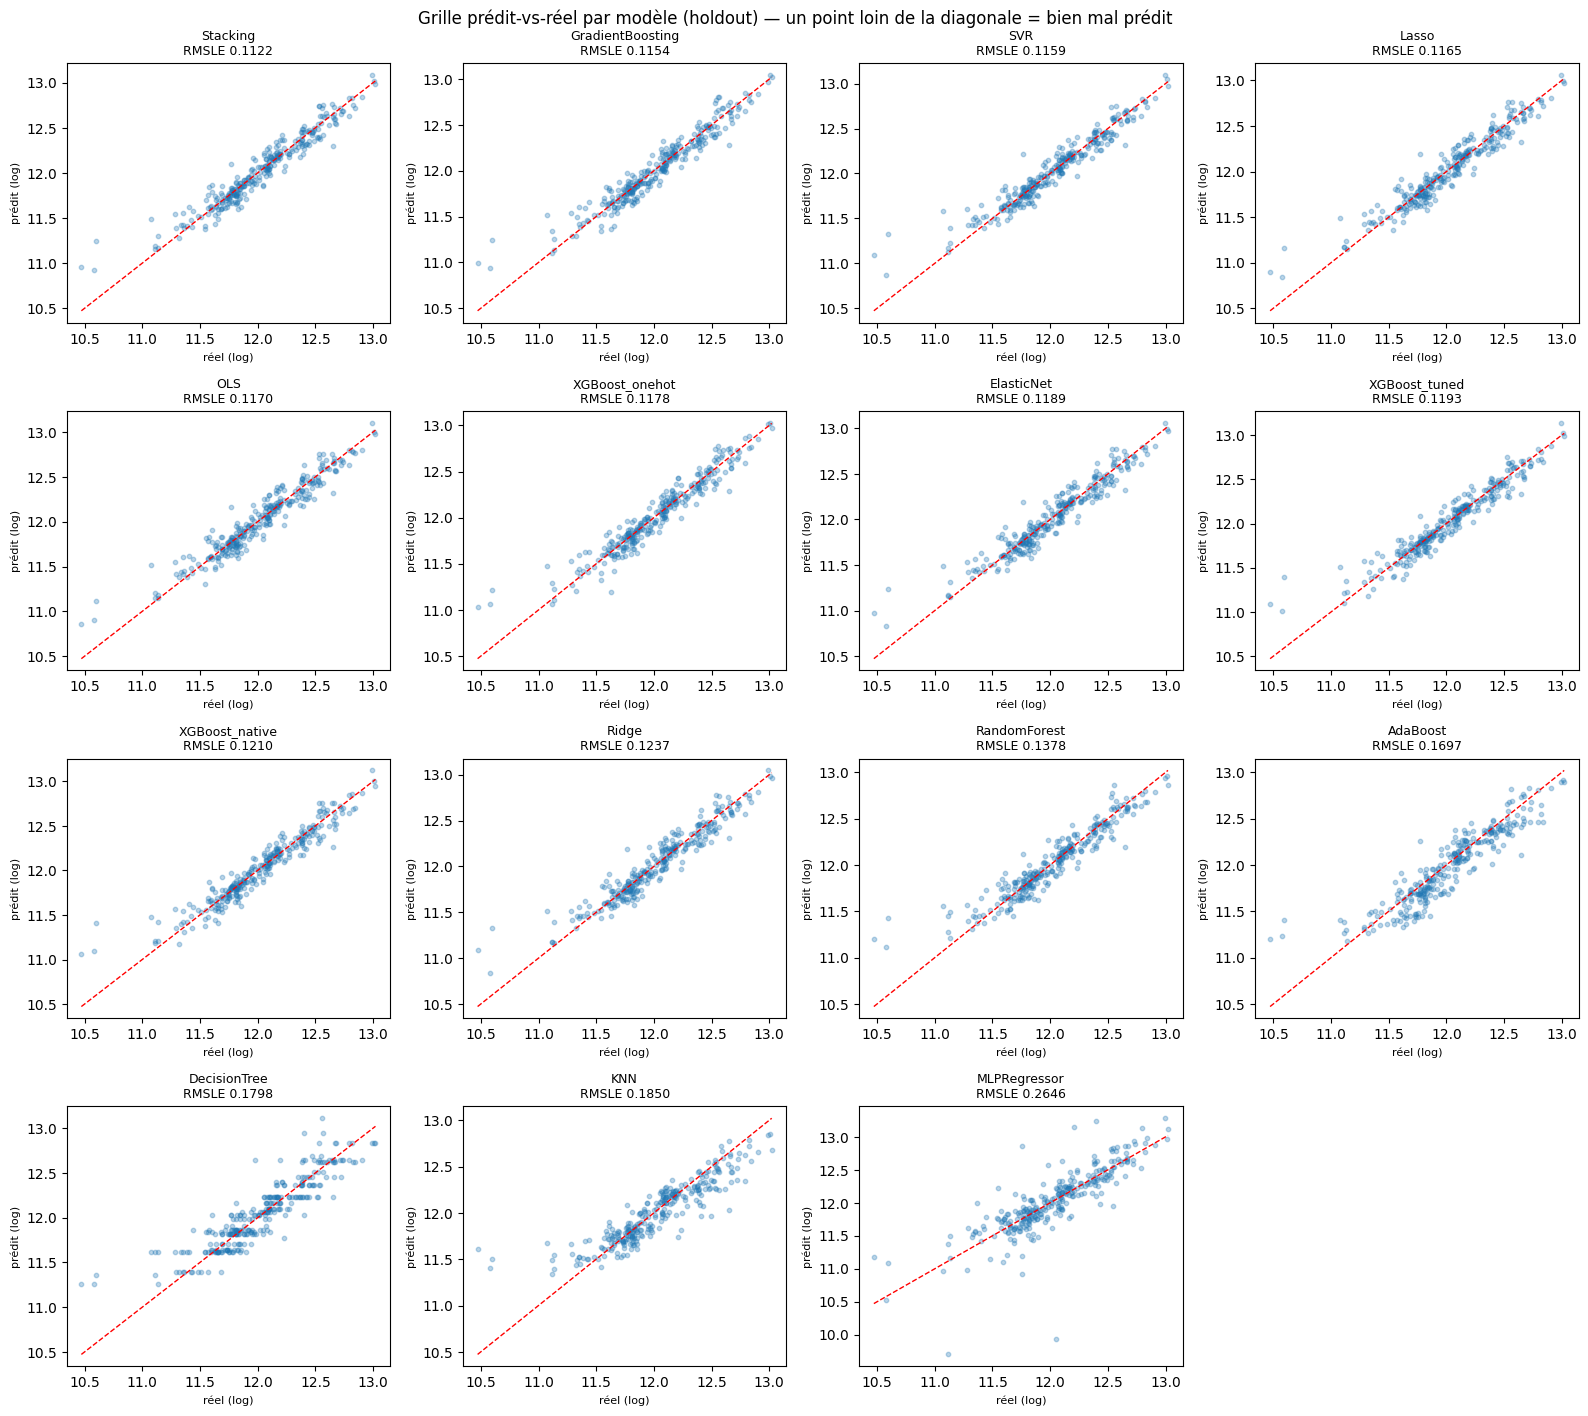

In [6]:
pred_files = sorted(RESULTS_DIR.glob('preds_*.npz'))
if not pred_files:
    print("Aucun fichier results/preds_*.npz — exécuter 3a–3d pour générer la grille.")
else:
    preds, y_true = {}, None
    for pf in pred_files:
        d = np.load(pf)
        for k in d.files:
            if k == 'y_true':
                y_true = d[k]
            else:
                preds[k] = d[k]

    ordered = [m for m in results_df['model'] if m in preds]   # trié par RMSLE holdout
    rmsle_by = dict(zip(results_df['model'], results_df['holdout_rmsle']))

    ncols = 4
    nrows = int(np.ceil(len(ordered) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)
    lo, hi = float(y_true.min()), float(y_true.max())
    for ax, m in zip(axes, ordered):
        ax.scatter(y_true, preds[m], alpha=0.3, s=10)
        ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
        ax.set_title(f"{m}\nRMSLE {rmsle_by.get(m, float('nan')):.4f}", fontsize=9)
        ax.set_xlabel('réel (log)', fontsize=8)
        ax.set_ylabel('prédit (log)', fontsize=8)
    for ax in axes[len(ordered):]:
        ax.axis('off')
    fig.suptitle("Grille prédit-vs-réel par modèle (holdout) — un point loin de la diagonale = bien mal prédit", fontsize=12)
    plt.tight_layout()
    plt.show()

## 5.6 Prochaines étapes
- **NB5** (`5_Assessment_Blueprint.ipynb`) chargera le champion via `results/winning_model.json` + l'artefact joblib et produira la soumission Kaggle.
- **MLflow** loggera chaque modèle de chaque famille comme une *run* distincte de la même expérience.
- **POC app** servira le champion via `mlflow models serve` derrière un formulaire Streamlit.